# Notebook to determine head and tail from a skeleton that has Head and Tail outside the skeleton

Find distances between points with the math.hypth function:
    https://stackoverflow.com/questions/5228383/how-do-i-find-the-distance-between-two-points

In [1]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff

from skimage.morphology import skeletonize

import cv2
import skan

In [2]:
#which image
#this is a coiled shape dict for worm:
#2020-07-01_18-36-25_control_worm6-channel-
coiled_shapes_dict={'ot1.tif':np.arange(2800,5603),
                    'ot2.tif':np.arange(6676,7300),
                    'ot3.tif':np.arange(18500,21000),
                    'ot4.tif':np.arange(21600,22345),
                    'ot5.tif':np.arange(24300,24900),
                    'ot6.tif':np.arange(27616,28200),
                    'ot7.tif':np.arange(34588,35400),
                    'ot8.tif':np.arange(38980,40000),
                    'ot9.tif':np.arange(47800,48600),
                    'ot10.tif':np.arange(59300,60100),
                    'ot11.tif':np.arange(62150,63340),
                    'ot12.tif':np.arange(93780,94100),
                    'ot13.tif':np.arange(108150,109350),
                    'ot14.tif':np.arange(116500,117200),
                    'ot15.tif':np.arange(163100,163600),
                    'ot16.tif':np.arange(165660,166690),
                    'ot17.tif':np.arange(171200,172400),
                    'ot18.tif':np.arange(172900,173960),
                    'ot19.tif':np.arange(194195,195000)}

In [3]:
#load hdf5 from DLC
path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_hdf5/2020-07-01_18-36-25_control_worm6-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_777500_filtered.h5'
df=pd.read_hdf(path)
scorer=df.columns.get_level_values(0)[0]

In [4]:
df.head(2)

scorer    DLC_resnet50_HeadTailAug10shuffle1_777500                         \
bodyparts                                      Head                          
coords                                            x           y likelihood   
0                                        262.066345  273.513733   0.999839   
1                                        263.297760  274.538544   0.999880   

scorer                                       
bodyparts       Tail                         
coords             x           y likelihood  
0          259.31546  237.086502   0.999962  
1          259.31546  238.335617   0.999721

In [5]:
#read hdf5 file with the head coordinates
x_head, y_head =df[scorer]['Head']['x'].values,df[scorer]['Head']['y'].values
#tail coords
x_tail, y_tail =df[scorer]['Tail']['x'].values,df[scorer]['Tail']['y'].values



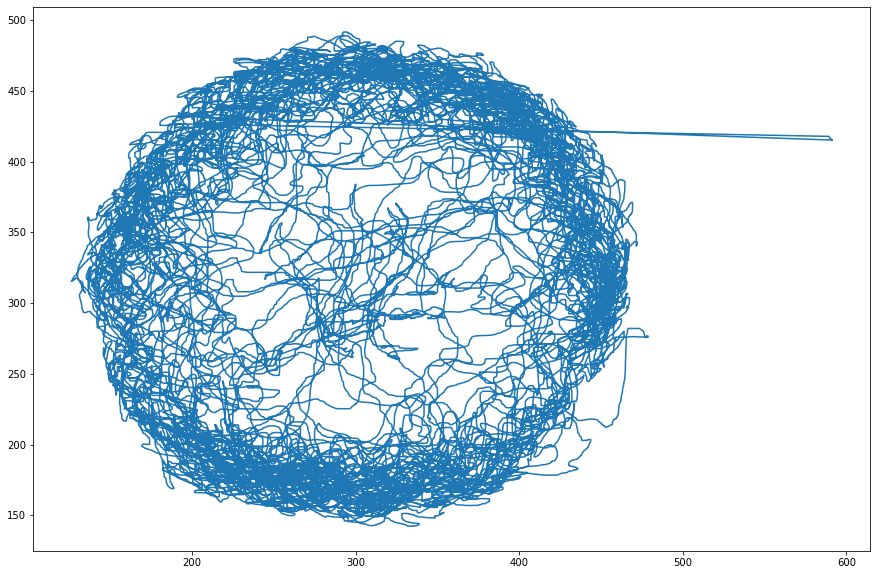

In [6]:
fig, ax=plt.subplots(figsize=(15,10))
ax.plot(x_head,y_head)

In [7]:
idx=1
x_head[idx]

263.2977600097656

In [8]:
#img_path

img_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeleton_after_new_unet/2020-07-01_18-36-25_control_worm6-channel-0-bigtiff_binary_200th.btf'
tif=tiff.TiffFile(img_path)

img=tif.pages[idx].asarray()

skel=skeletonize(img/255)

labeled_img=img.copy()
#cv2.drawKeypoints(img,, labeled_img,)
labeled_img=cv2.circle(labeled_img, (int(x_head[idx]), int(y_head[idx])), 10, (200,200,200), 2)
labeled_img=cv2.circle(labeled_img, (int(x_tail[idx]), int(y_tail[idx])), 10, (200,200,200), 2)



In [9]:
#get skeleton tips coordinates (could they be more than 2?, i am afraid so)
#using skan package? or manually input for the time being
from skan import skeleton_to_csgraph


pixel_graph, coordinates, degrees = skeleton_to_csgraph(skel)

#tiff.imwrite('degrees.tiff', degrees.astype(np.uint8))

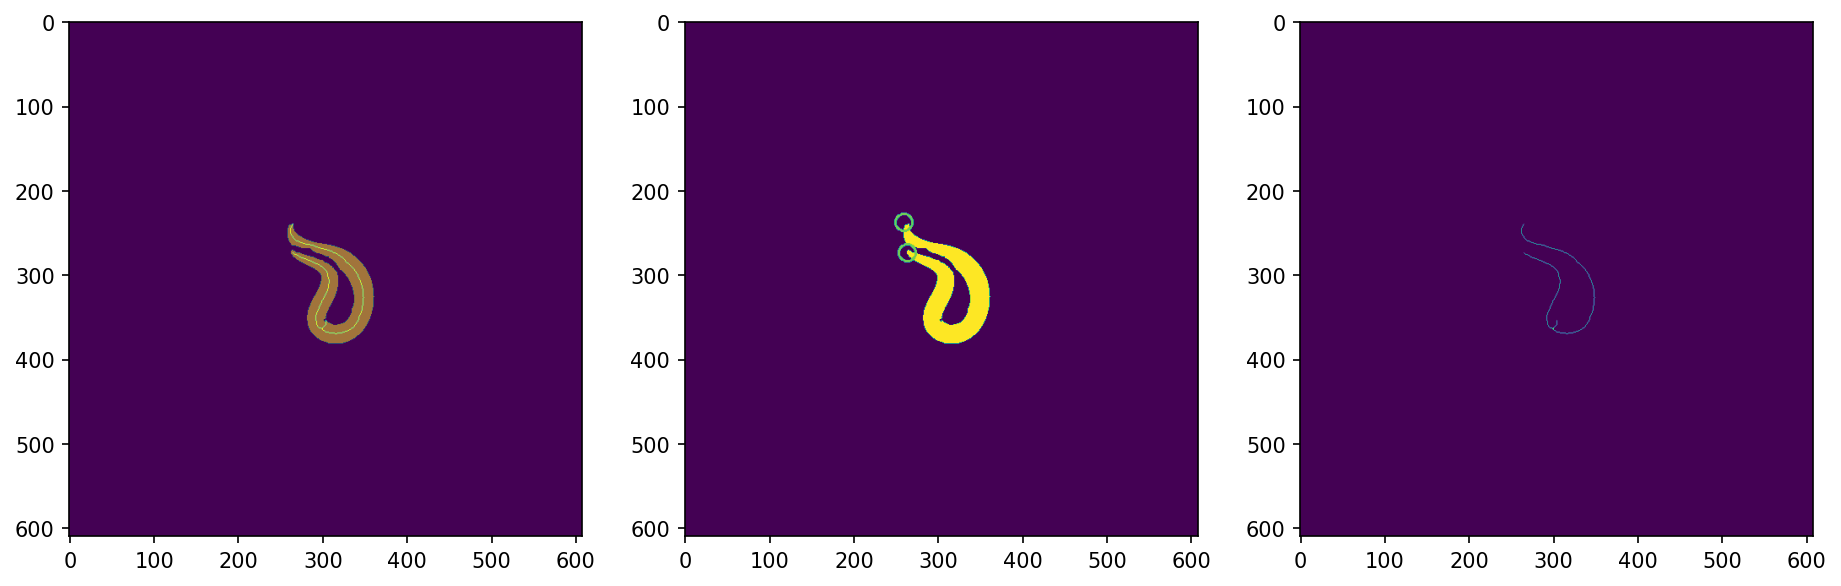

In [10]:
#plotting
fig, axes =plt.subplots(figsize=(15,5), ncols=3, nrows=1,dpi=150)

axes[0].imshow(img)
axes[0].imshow(skel, alpha=.5)
axes[1].imshow(labeled_img)
axes[2].imshow(degrees)
    

In [11]:
degrees

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

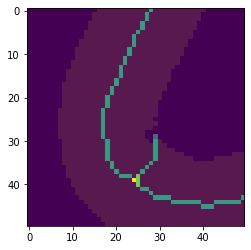

In [12]:
plt.imshow(img[325:375,275:325])
plt.imshow(degrees[325:375,275:325], alpha=0.9)

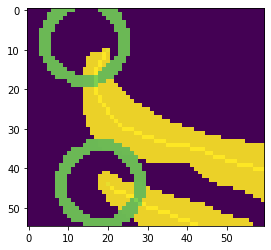

In [13]:
plt.imshow(img[230:285,245:305])
plt.imshow(degrees[230:285,245:305], alpha=0.9)
plt.imshow(labeled_img[230:285,245:305], alpha=0.9)

In [14]:
coords=np.where(degrees==1)
coords

(array([240, 274, 354]), array([265, 265, 304]))

In [15]:
list(zip(*coords))

[(240, 265), (274, 265), (354, 304)]

In [16]:
#gets the edge coordinates and puts them on a list of tuples
edge_coords=list(zip(*np.where(degrees==1)))
print(edge_coords)

[(240, 265), (274, 265), (354, 304)]


## Trying it with lists and numpy arrays

See below for the attempt with dataframes

In [17]:
total_sum=[]
#loop through every ending/edge
for i, (x,y) in enumerate(edge_coords):
    #calculate the distance from that ending to the body part
    dist_head = math.hypot(x - x_head[idx], y - y_head[idx])
    dist_tail = math.hypot(x - x_tail[idx], y - y_tail[idx])
    print('x:', x, ' y:', y)
    print('distance from point ', i, 'to head ', dist_head)
    print('distance from point ', i, 'to tail ', dist_tail)
    total_sum.append(dist_head+dist_tail)

x: 240  y: 265
distance from point  0 to head  25.174777802630157
distance from point  0 to tail  32.925314276637685
x: 274  y: 265
distance from point  1 to head  14.336030020467225
distance from point  1 to tail  30.440516195853984
x: 354  y: 304
distance from point  2 to head  95.36704748755636
distance from point  2 to tail  115.22574912906417


In [18]:
#MAYBE it would be better to loop for every body part:
for i, bodypart in enumerate(bodyparts):
    dist=math.hypoth(bodypart[idx], point)

NameError: name 'bodyparts' is not defined

In [21]:
#find the minimal cost combination

distances_head=[25,14,95]
distances_tail=[32,30,115]

In [22]:
#test
# distances_head=list(np.arange(1,6,1))
# distances_tail=list(np.arange(1,6,1))

In [23]:
distances_tail

[32, 30, 115]

In [37]:
#Some sums are not valid because they correspond to one point being the closest to the two ends of the centerline
bad_ones=result_np[np.arange(0, len(result), len(distances_tail)+1)]
print(bad_ones)
bad_ones=np.arange(0, len(result), len(distances_tail)+1)
bad_ones

[nan nan nan]


array([0, 4, 8])

In [25]:
#this is creating a list
import itertools

somelists = [
   distances_head,
   distances_tail]

#result list
result=[]

for x,y in itertools.product(*somelists):
    print(x+y)
    result.append(x+y)

57
55
140
46
44
129
127
125
210


In [38]:
#convert the list into numpy array type float
result_np=np.array(result, dtype=float)

In [39]:
result_np = result_np.astype(float)

In [40]:
#Some sums are not valid because they correspond to one point being the closest to the two ends of the centerline
bad_ones=result_np[np.arange(0, len(result), len(distances_tail)+1)]
bad_ones

array([ 57.,  44., 210.])

In [41]:
#non valid indexes
invalid_indexes=np.arange(0, len(result), len(distances_tail)+1)

In [42]:
result_np[invalid_indexes] = np.nan

In [43]:
result_np

array([ nan,  55., 140.,  46.,  nan, 129., 127., 125.,  nan])

In [44]:
#find the nanmin
np.nanmin(result_np)

46.0

In [45]:
#find where the nanmin is
min_combination=np.where(result_np==np.nanmin(result_np))

In [49]:
min_combination[0][0]

3

In [48]:
somelists[min_combination[0][0]]

IndexError: list index out of range

In [50]:
result_np==np.nanmin(result_np)

array([False, False, False,  True, False, False, False, False, False])

In [51]:
np.where(result_np[invalid_indexes], np.nan)

ValueError: either both or neither of x and y should be given

In [52]:
result_np

array([ nan,  55., 140.,  46.,  nan, 129., 127., 125.,  nan])

In [53]:
#calculate the min
min_sum=np.where(result_np==result_np.min())
min_sum

(array([], dtype=int64),)

In [54]:
calculate min in a for loop excluding the value for values on the invalid_indexes
for invalid_index in invalid_indexes:
    min_sum=np.where(result_np==result_np.min())
    if min_sum in invalid_indexes:
        

SyntaxError: invalid syntax (<ipython-input-54-b3f48ae685f6>, line 1)

In [55]:
#is the min sum one of the not valid indexes? then do something and search for another min
result_np[min_sum]

array([], dtype=float64)

In [56]:
#remove the combinations that arise from the same element of the list
x = np.delete(result, np.arange(0, len(result), len(distances_tail)+1))

# With dataframes
Now that I have solved the problem, I think it is better to do it with dataframes.

In [57]:
import itertools

In [66]:
#import package
from skan import skeleton_to_csgraph

def get_skeleton_points(skel, number_of_neighbors):
    """
    Returns coordinates of points in the skeleton that have the specified number of neighbors
    endpoints have 1 neighbor, junctions 2, branches have 3 or more, etc.
    Parameters:
    -----------
    skel, np.array
    skeleton obtain from skeletonize from scikit image
    neighbors, int
    number of neighbors that the points should have
    Returns:
    -----------
    edge_coordiantes, list
    list of tuples with the coordinates of the edges
    """


    #obtain the degrees of each skeleton coordinate
    pixel_graph, coordinates, degrees = skeleton_to_csgraph(skel)
    
    skel_points_coords=list(zip(*np.where(degrees==number_of_neighbors)))

    
    return skel_points_coords

In [67]:
#load hdf5 from DLC
path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_hdf5/2020-07-01_18-36-25_control_worm6-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_777500_filtered.h5'
df=pd.read_hdf(path)
scorer=df.columns.get_level_values(0)[0]

In [68]:
idx=1

In [69]:
#read hdf5 file with the head coordinates
x_head, y_head =df[scorer]['Head']['x'].values,df[scorer]['Head']['y'].values
#tail coords
x_tail, y_tail =df[scorer]['Tail']['x'].values,df[scorer]['Tail']['y'].values

In [70]:
#These arrays have been loaded before and contain the x and y head and tail coordinates
x_head, y_head, x_tail, y_tail

(array([262.06634521, 263.29776001, 264.32098389, ..., 425.12677002,
        424.11767578, 423.37286377]),
 array([273.51373291, 274.5385437 , 275.83279419, ..., 399.79043579,
        399.79043579, 399.79043579]),
 array([259.31546021, 259.31546021, 259.46710205, ..., 184.30970764,
        184.25964355, 184.25964355]),
 array([237.08650208, 238.33561707, 238.49293518, ..., 324.46447754,
        324.00952148, 323.28881836]))

In [71]:
#img_path

img_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeleton_after_new_unet/2020-07-01_18-36-25_control_worm6-channel-0-bigtiff_binary_200th.btf'
tif=tiff.TiffFile(img_path)

img=tif.pages[idx].asarray()

skel=skeletonize(img/255)


In [72]:
pixel_graph, coordinates, degrees = skeleton_to_csgraph(skel)


In [73]:
number_of_neighbours=1
edge_coords=get_skeleton_points(skel, number_of_neighbours)

In [74]:
print(edge_coords)

[(240, 265), (274, 265), (354, 304)]


In [75]:
#label edge_coords
edges_img=img.copy()

for point in edge_coords:
    print(point)
    #points need to be inverted in the tuple because of matplotlib and array 0,0 coordinate are different
    edges_img=cv2.circle(edges_img, point[::-1], 10, (200,200,200), 2)

(240, 265)
(274, 265)
(354, 304)


In [76]:
#label head and tail
labeled_img=img.copy()

labeled_img=cv2.circle(labeled_img, (int(x_head[idx]), int(y_head[idx])), 10, (200,200,200), 2)
labeled_img=cv2.circle(labeled_img, (int(x_tail[idx]), int(y_tail[idx])), 10, (200,200,200), 2)

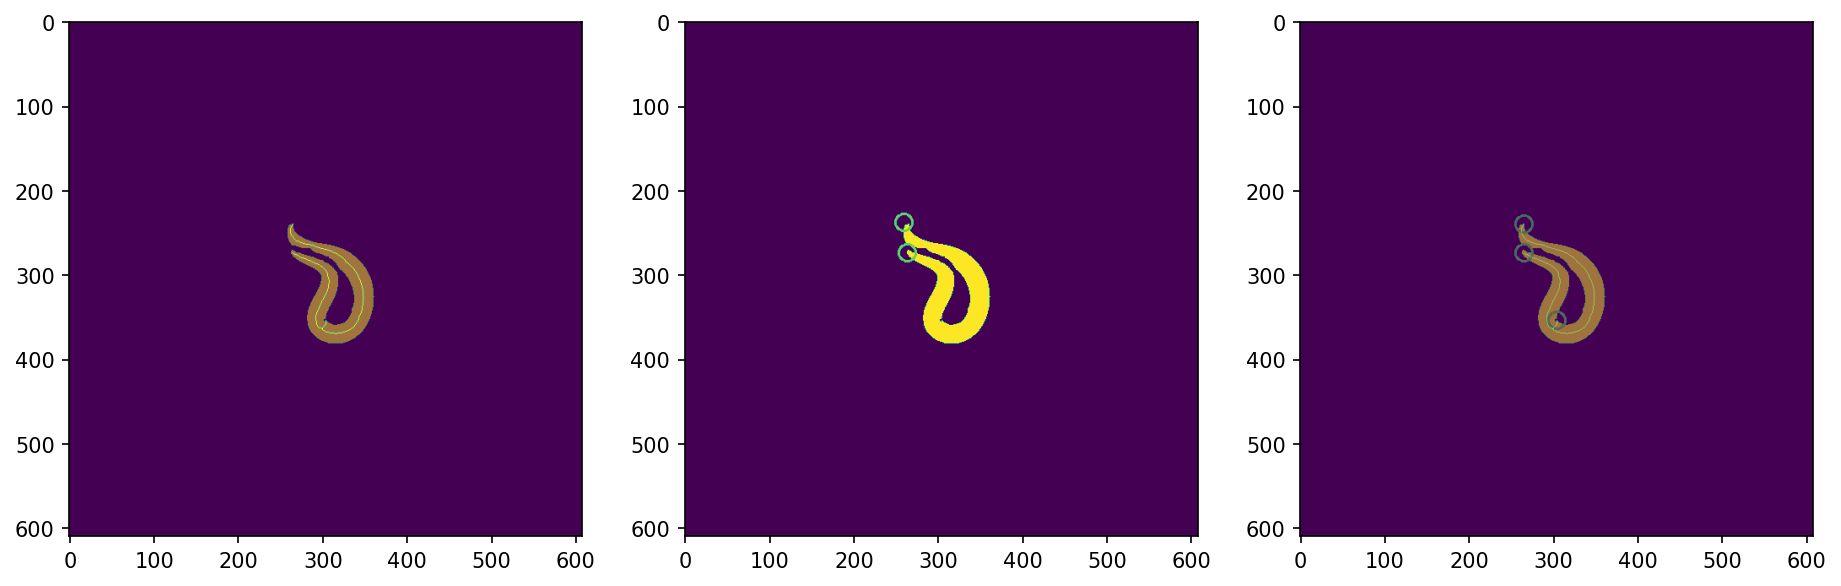

In [77]:
#plotting
fig, axes =plt.subplots(figsize=(15,5), ncols=3, nrows=1,dpi=150)

axes[0].imshow(img)
axes[0].imshow(skel, alpha=.5)
axes[1].imshow(labeled_img)
axes[2].imshow(degrees)
axes[2].imshow(edges_img, alpha=.5)

In [79]:
number_of_edges=len(edge_coords)

In [80]:
#create a dataframe which will contain all the info for every frame
df=pd.DataFrame()

In [81]:
total_sum=[]
#loop through every ending/edge
for i, (x,y) in enumerate(edge_coords):
    
    df.loc[i, 'edge_x_coords']=x
    df.loc[i, 'edge_y_coords']=y
    #store head and tail position
    df.loc[i, 'head_x']=x_head[idx]
    df.loc[i, 'head_y']=y_head[idx]

    
    df.loc[i, 'tail_x']=x_tail[idx]
    df.loc[i, 'tail_y']=y_tail[idx]
    
    #calculate the distance from that ending to the body part
    df.loc[i, 'dist_edge_to_head'] = math.hypot(x - x_head[idx], y - y_head[idx])
    df.loc[i, 'dist_edge_to_tail'] = math.hypot(x - x_tail[idx], y - y_tail[idx])
#     print('x:', x, ' y:', y)
#     print('distance from point ', i, 'to head ', dist_head)
#     print('distance from point ', i, 'to tail ', dist_tail)
#     total_sum.append(dist_head+dist_tail)

In [82]:
df

,edge_x_coords,edge_y_coords,head_x,head_y,tail_x,tail_y,dist_edge_to_head,dist_edge_to_tail
0,240.0,265.0,263.29776,274.538544,259.31546,238.335617,25.174778,32.925314
1,274.0,265.0,263.29776,274.538544,259.31546,238.335617,14.336030,30.440516
2,354.0,304.0,263.29776,274.538544,259.31546,238.335617,95.367047,115.225749


In [83]:
#save the distances into list
somelists = [
   df.loc[:,'dist_edge_to_head'],
   df.loc[:,'dist_edge_to_tail']]

In [84]:
somelists

[0    25.174778
 1    14.336030
 2    95.367047
 Name: dist_edge_to_head, dtype: float64,
 0     32.925314
 1     30.440516
 2    115.225749
 Name: dist_edge_to_tail, dtype: float64]

In [85]:
#with itertools we calculate the product of all the distance combinations (aka cartesian product)
#and save them in the dataframe

for i, (dist1,dist2) in enumerate(itertools.product(*somelists)):
    print(i,dist1,dist2)
    df.loc[i,'dist1']=dist1
    df.loc[i,'dist2']=dist2
    #df.loc[i,'distance sum']=dist1+dist2 #name it something better

0 25.174777802630157 32.925314276637685
1 25.174777802630157 30.440516195853984
2 25.174777802630157 115.22574912906417
3 14.336030020467225 32.925314276637685
4 14.336030020467225 30.440516195853984
5 14.336030020467225 115.22574912906417
6 95.36704748755636 32.925314276637685
7 95.36704748755636 30.440516195853984
8 95.36704748755636 115.22574912906417


In [86]:
df

,edge_x_coords,edge_y_coords,head_x,head_y,tail_x,tail_y,dist_edge_to_head,dist_edge_to_tail,dist1,dist2
0,240.0,265.0,263.29776,274.538544,259.31546,238.335617,25.174778,32.925314,25.174778,32.925314
1,274.0,265.0,263.29776,274.538544,259.31546,238.335617,14.336030,30.440516,25.174778,30.440516
2,354.0,304.0,263.29776,274.538544,259.31546,238.335617,95.367047,115.225749,25.174778,115.225749
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.336030,32.925314
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.336030,30.440516
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.336030,115.225749
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.367047,32.925314
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.367047,30.440516
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.367047,115.225749


In [87]:
#sum the two distances
df['distance_sum']=df['dist1']+df['dist2']

In [88]:
len(df['dist_edge_to_head'])

9

In [89]:
(number_of_edges)+1

4

In [90]:
values_to_exclude=np.arange(0, len(df['dist_edge_to_head']), number_of_edges+1)
values_to_exclude

array([0, 4, 8])

In [91]:
df.loc[values_to_exclude,'distance_sum']=np.nan

In [92]:
df

,edge_x_coords,edge_y_coords,head_x,head_y,tail_x,tail_y,dist_edge_to_head,dist_edge_to_tail,dist1,dist2,distance_sum
0,240.0,265.0,263.29776,274.538544,259.31546,238.335617,25.174778,32.925314,25.174778,32.925314,NaN
1,274.0,265.0,263.29776,274.538544,259.31546,238.335617,14.336030,30.440516,25.174778,30.440516,55.615294
2,354.0,304.0,263.29776,274.538544,259.31546,238.335617,95.367047,115.225749,25.174778,115.225749,140.400527
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.336030,32.925314,47.261344
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.336030,30.440516,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.336030,115.225749,129.561779
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.367047,32.925314,128.292362
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.367047,30.440516,125.807564
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.367047,115.225749,NaN


In [93]:
df['distance_sum'].min()

47.26134429710491

In [94]:
#find the row where the distance sum is the minimum
df[df['distance_sum']==df['distance_sum'].min()]

,edge_x_coords,edge_y_coords,head_x,head_y,tail_x,tail_y,dist_edge_to_head,dist_edge_to_tail,dist1,dist2,distance_sum
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.33603,32.925314,47.261344


In [95]:
#find the dist1 where distance sum is the minimum
dist1_good=df['dist1'][df['distance_sum']==df['distance_sum'].min()]
dist1_good

3    14.33603
Name: dist1, dtype: float64

In [96]:
#find the dist2 where distance sum is the minimum
dist2_good=df['dist2'][df['distance_sum']==df['distance_sum'].min()]
dist2_good

3    32.925314
Name: dist2, dtype: float64

In [97]:
dist1_good.values, dist2_good.values

(array([14.33603002]), array([32.92531428]))

In [98]:
df['dist_edge_to_head']

0    25.174778
1    14.336030
2    95.367047
3          NaN
4          NaN
5          NaN
6          NaN
7          NaN
8          NaN
Name: dist_edge_to_head, dtype: float64

### This row finally has the head coordinates!!

In [99]:
dist1_good.values[0]

14.336030020467225

In [100]:
np.where(df['dist_edge_to_head']==dist1_good.values[0])

(array([1]),)

In [101]:
#find the edge coords that have dist_edge_to_head the dist1_good
df[df['dist_edge_to_head']==dist1_good.values[0]]

,edge_x_coords,edge_y_coords,head_x,head_y,tail_x,tail_y,dist_edge_to_head,dist_edge_to_tail,dist1,dist2,distance_sum
1,274.0,265.0,263.29776,274.538544,259.31546,238.335617,14.33603,30.440516,25.174778,30.440516,55.615294


### And This row finally has the tail coordinates!!

In [102]:
dist2_good.values[0]

32.925314276637685

In [103]:
np.where(df['dist_edge_to_tail']==dist2_good.values[0])

(array([0]),)

In [104]:
#find the edge coords that have dist_edge_to_head the dist1_good

df[df['dist_edge_to_tail']==dist2_good.values[0]]

,edge_x_coords,edge_y_coords,head_x,head_y,tail_x,tail_y,dist_edge_to_head,dist_edge_to_tail,dist1,dist2,distance_sum
0,240.0,265.0,263.29776,274.538544,259.31546,238.335617,25.174778,32.925314,25.174778,32.925314,NaN


# With dataframes and functions

In [105]:
def find_head_and_tail():
    """
    
    Parameters:
    -----------
    Returns:
    -----------
    """

def paired_closest_neighbors(paired_coordinates,candidate_coordinates):
    """
    Parameters:
    -----------
    Returns:
    -----------
    """
    return candidate_coordinate1, candidate_coordinate2

